# Autoencoder per Anomaly Detection — Serie storiche di traffico
**Pipeline**: long format → campionamento wide → tf.data → Keras autoencoder → soglia MAE


## 1. Import

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

## 2. Parametri


In [2]:
# ── Periodo di training ───────────────────────────────────────────────────────
START_TRAIN = "2025-01-01"   # inizio periodo di training
END_TRAIN   = "2026-02-01"   # fine  periodo di training

# ── Campionamento ─────────────────────────────────────────────────────────────
N_GIORNI_CAMP = 90           # lunghezza finestra in giorni
N_CAMPIONI    = 50000        # finestre da estrarre per il training
FEATURE_COLS  = ["count_traffico"]

# ── Modello ───────────────────────────────────────────────────────────────────
BATCH_SIZE        = 256
EPOCHS            = 50
LATENT_DIM        = 64      # dimensione del bottleneck
SOGLIA_PERCENTILE = 95      # percentile MAE per la soglia di anomalia

# ── Iperparametri architettura ────────────────────────────────────────────────
LAYER_1 = 512
LAYER_2 = 256
DROPOUT = 0.2
LEARNING_RATE = 1e-3

# ── Riproducibilità ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 3. Caricamento e preprocessing


In [3]:
import os
import glob

# ── Parametri ─────────────────────────────────────────────────────────────────
CARTELLA_PARQUET  = "C:/Users/sissilollo/OneDrive - Alma Mater Studiorum Università di Bologna/Desktop/Nowcasting - Giacobazzi/output_province"
N_PARQUET         = 107 # queste province non entrano nel training
PROVINCE_ESCLUSE = []
# ─────────────────────────────────────────────────────────────────────────────

def load_and_preprocess_single(path: str) -> pd.DataFrame:
    """Carica e preprocessa un singolo parquet."""
    df = pd.read_parquet(path)
    df["giorno"] = pd.to_datetime(df["giorno"])
    df["ora"]    = df["ora"].astype(int)

    mask = (df["giorno"] >= START_TRAIN) & (df["giorno"] <= END_TRAIN)
    df   = df.loc[mask].copy()

    giorni_range = pd.date_range(START_TRAIN, END_TRAIN, freq="D")
    ore          = list(range(24))
    serie_keys   = df[["comune_amm", "zona"]].drop_duplicates()

    griglia = (
        serie_keys
        .merge(pd.DataFrame({"giorno": giorni_range}), how="cross")
        .merge(pd.DataFrame({"ora": ore}),             how="cross")
    )

    df = griglia.merge(
        df[["comune_amm", "zona", "giorno", "ora", "count_traffico", "velocita_avg"]],
        on=["comune_amm", "zona", "giorno", "ora"],
        how="left"
    )

    df = df.sort_values(["comune_amm", "zona", "giorno", "ora"]).reset_index(drop=True)
    df["count_traffico"] = df["count_traffico"].fillna(0)
    df["velocita_avg"]   = df["velocita_avg"].fillna(0)

    return df


def load_and_preprocess(cartella: str, n_parquet: int = None) -> pd.DataFrame:
    all_paths = sorted(glob.glob(os.path.join(cartella, "*.parquet")))

    if not all_paths:
        raise FileNotFoundError(f"Nessun parquet trovato in: {cartella}")

    # Escludi le province di test
    paths = [
        p for p in all_paths
        if not any(
            os.path.basename(p).replace(".parquet", "").endswith(pr)
            for pr in PROVINCE_ESCLUSE
        )
    ]

    esclusi = [os.path.basename(p) for p in all_paths if p not in paths]
    print(f"Parquet totali   : {len(all_paths)}")
    print(f"Esclusi (test)   : {esclusi}")
    print(f"Disponibili      : {len(paths)}")

    if n_parquet is not None:
        rng   = np.random.default_rng(RANDOM_SEED)
        paths = list(rng.choice(paths, size=min(n_parquet, len(paths)), replace=False))

    print(f"Parquet usati    : {len(paths)}")
    print()

    frames = []
    for path in paths:
        nome = os.path.basename(path)
        df_p = load_and_preprocess_single(path)
        print(f"  ✓ {nome:30s} → {df_p.groupby(['comune_amm','zona']).ngroups} serie  |  {len(df_p):,} righe")
        frames.append(df_p)

    df = pd.concat(frames, ignore_index=True)
    return df


df = load_and_preprocess(CARTELLA_PARQUET, N_PARQUET)

print()
print(f"Righe totali nel periodo di training : {len(df):,}")
print(f"Serie uniche (comune x zona)         : {df.groupby(['comune_amm','zona']).ngroups}")
print(f"Periodo                               : {df['giorno'].min().date()} → {df['giorno'].max().date()}")
print(f"NaN residui                           : {df[['count_traffico','velocita_avg']].isna().sum().to_dict()}")
display(df.head())

Parquet totali   : 107
Esclusi (test)   : []
Disponibili      : 107
Parquet usati    : 107

  ✓ traffico_VT.parquet            → 181 serie  |  1,724,568 righe
  ✓ traffico_AV.parquet            → 393 serie  |  3,744,504 righe
  ✓ traffico_LC.parquet            → 234 serie  |  2,229,552 righe
  ✓ traffico_IS.parquet            → 126 serie  |  1,200,528 righe
  ✓ traffico_CH.parquet            → 260 serie  |  2,477,280 righe
  ✓ traffico_PN.parquet            → 153 serie  |  1,457,784 righe
  ✓ traffico_BI.parquet            → 181 serie  |  1,724,568 righe
  ✓ traffico_PI.parquet            → 122 serie  |  1,162,416 righe
  ✓ traffico_CZ.parquet            → 321 serie  |  3,058,488 righe
  ✓ traffico_SR.parquet            → 122 serie  |  1,162,416 righe
  ✓ traffico_LT.parquet            → 183 serie  |  1,743,624 righe
  ✓ traffico_TO.parquet            → 948 serie  |  9,032,544 righe
  ✓ traffico_FR.parquet            → 320 serie  |  3,048,960 righe
  ✓ traffico_CE.parquet            → 

,comune_amm,zona,giorno,ora,count_traffico,velocita_avg
0,A040,B1,2025-01-01,0,3.0,35.3
1,A040,B1,2025-01-01,1,5.0,34.0
2,A040,B1,2025-01-01,2,1.0,48.0
3,A040,B1,2025-01-01,3,1.0,51.0
4,A040,B1,2025-01-01,4,0.0,0.0


## 4. Campionamento e Scaling wide

In [4]:

class SeriesScaler:
    """
    Normalizza ogni campione usando la media e la std storica della propria
    serie (comune_amm, zona), calcolate sull'intero periodo di training.
    A differenza del RowStandardScaler, preserva l'informazione sul livello
    assoluto: una finestra strutturalmente bassa rispetto alla norma della
    serie risultera' sistematicamente negativa dopo la trasformazione.
    """

    def __init__(self):
        self.stats_ = {}   # (comune_amm, zona) -> {"mu": float, "std": float}

    def transform_single(self, x, key):
        """
        Scala un singolo vettore 1D usando le statistiche della serie key.
        Ritorna (x_scaled, mu, std).
        """
        if key not in self.stats_:
            raise KeyError(f"Serie non trovata nello scaler: {key}")
        mu  = self.stats_[key]["mu"]
        std = self.stats_[key]["std"]
        x_scaled = (x.reshape(1, -1) - mu) / std
        return x_scaled, mu, std

    def transform_batch(self, X_raw, keys):
        """
        Scala un batch di vettori, uno per chiave.
        X_raw: shape (n, features), keys: lista di (comune_amm, zona) len n.
        """
        out = np.empty_like(X_raw, dtype=np.float32)
        for i, key in enumerate(keys):
            mu  = self.stats_[key]["mu"]
            std = self.stats_[key]["std"]
            out[i] = (X_raw[i] - mu) / std
        return out

    @staticmethod
    def inverse_transform_single(x_scaled, mu, std):
        return x_scaled * std + mu

    def to_dict(self):
        """Serializza le statistiche per il salvataggio su JSON."""
        return {f"{k[0]}|{k[1]}": v for k, v in self.stats_.items()}

    @classmethod
    def from_dict(cls, d):
        """Ricostruisce lo scaler da un dict caricato da JSON."""
        sc = cls()
        sc.stats_ = {
            (parts[0], parts[1]): v
            for raw_key, v in d.items()
            for parts in [raw_key.split("|")]
        }
        return sc

## 5. Calcolo statistiche globali per serie (tutte le province)

Calcoliamo `mu` e `std` per ogni coppia `(comune_amm, zona)` iterando su **tutti**  
i parquet disponibili, **province di test incluse**. Questo passaggio è indipendente  
dal training: le statistiche sono una proprietà intrinseca di ciascuna serie e  
devono essere disponibili anche per le province che non entrano nel training set.

In [5]:
def build_serie_stats_global(cartella: str) -> dict:
    """
    Itera su tutti i parquet nella cartella (nessuna provincia esclusa)
    e calcola mu e std per ogni coppia (comune_amm, zona).
    Ritorna dict (comune_amm, zona) -> {"mu": float, "std": float}.
    """
    all_paths = sorted(glob.glob(os.path.join(cartella, "*.parquet")))
    if not all_paths:
        raise FileNotFoundError(f"Nessun parquet trovato in: {cartella}")

    print(f"Parquet totali (incluse province di test): {len(all_paths)}")
    stats = {}

    for path in all_paths:
        nome = os.path.basename(path)
        df_p = pd.read_parquet(path)
        df_p["giorno"] = pd.to_datetime(df_p["giorno"])
        df_p["ora"]    = df_p["ora"].astype(int)

        # Filtra sul periodo di training per coerenza con i dati visti dal modello
        mask = (df_p["giorno"] >= START_TRAIN) & (df_p["giorno"] <= END_TRAIN)
        df_p = df_p.loc[mask]

        n_serie = 0
        for (comune, zona), grp in df_p.groupby(["comune_amm", "zona"]):
            vals = grp["count_traffico"].fillna(0).values.astype(np.float64)
            mu   = float(vals.mean())
            std  = float(vals.std())
            std  = std if std > 0 else 1.0
            stats[(comune, zona)] = {"mu": mu, "std": std}
            n_serie += 1

        print(f"  ✓ {nome:35s} -> {n_serie} serie")

    print(f"\nStatistiche calcolate per {len(stats):,} serie totali.")
    return stats


serie_stats_global = build_serie_stats_global(CARTELLA_PARQUET)

# Costruisce lo scaler globale e lo salva subito — indipendente dal training
scaler_global = SeriesScaler()
scaler_global.stats_ = serie_stats_global

import json as _json
with open("serie_stats.json", "w") as f:
    _json.dump(scaler_global.to_dict(), f, indent=2)

print(f"Salvato: serie_stats.json  ({len(serie_stats_global):,} serie)")

# Lo scaler globale e' gia' stato costruito nella sezione 3-bis.
# Lo renominiamo per coerenza con il resto del codice.
scaler = scaler_global
print(f"SeriesScaler pronto: {len(scaler.stats_):,} serie (tutte le province)")
esempio = list(scaler.stats_.items())[0]
print(f"Esempio — {esempio[0]}: mu={esempio[1]['mu']:.2f}, std={esempio[1]['std']:.2f}")


Parquet totali (incluse province di test): 107
  ✓ traffico_AG.parquet                 -> 207 serie
  ✓ traffico_AL.parquet                 -> 429 serie
  ✓ traffico_AN.parquet                 -> 181 serie
  ✓ traffico_AO.parquet                 -> 201 serie
  ✓ traffico_AP.parquet                 -> 125 serie
  ✓ traffico_AQ.parquet                 -> 249 serie
  ✓ traffico_AR.parquet                 -> 119 serie
  ✓ traffico_AT.parquet                 -> 265 serie
  ✓ traffico_AV.parquet                 -> 393 serie
  ✓ traffico_BA.parquet                 -> 296 serie
  ✓ traffico_BG.parquet                 -> 566 serie
  ✓ traffico_BI.parquet                 -> 181 serie
  ✓ traffico_BL.parquet                 -> 227 serie
  ✓ traffico_BN.parquet                 -> 185 serie
  ✓ traffico_BO.parquet                 -> 293 serie
  ✓ traffico_BR.parquet                 -> 106 serie
  ✓ traffico_BS.parquet                 -> 664 serie
  ✓ traffico_BT.parquet                 -> 80 serie


## 6. Campionamento serie storiche


In [6]:
def build_series_index(df: pd.DataFrame) -> dict:
    """Ritorna dict (comune_amm, zona) → DataFrame pivot giornaliero."""
    series_index = {}
    for (comune, zona), grp in df.groupby(["comune_amm", "zona"]):
        pivot = grp.pivot_table(
            index="giorno",
            columns="ora",
            values=FEATURE_COLS,
            aggfunc="first"
        )
        pivot.columns = [f"{feat}_{int(h)}" for feat, h in pivot.columns]
        pivot = pivot.sort_index()
        series_index[(comune, zona)] = pivot
    return series_index

series_index = build_series_index(df)

print(f"Serie indicizzate: {len(series_index)}")
esempio_key = list(series_index.keys())[0]
esempio_pivot = series_index[esempio_key]
print(f"\nEsempio serie {esempio_key}:")
print(f"  Giorni disponibili : {len(esempio_pivot)}")
print(f"  Colonne (prime 6)  : {list(esempio_pivot.columns[:6])}")
display(esempio_pivot)

Serie indicizzate: 27154

Esempio serie ('A001', 'B1'):
  Giorni disponibili : 397
  Colonne (prime 6)  : ['count_traffico_0', 'count_traffico_1', 'count_traffico_2', 'count_traffico_3', 'count_traffico_4', 'count_traffico_5']


,count_traffico_0,count_traffico_1,count_traffico_2,count_traffico_3,count_traffico_4,count_traffico_5,count_traffico_6,count_traffico_7,count_traffico_8,count_traffico_9,...,count_traffico_14,count_traffico_15,count_traffico_16,count_traffico_17,count_traffico_18,count_traffico_19,count_traffico_20,count_traffico_21,count_traffico_22,count_traffico_23
giorno,,,,,,,,,,,,,,,,,,,,,
2025-01-01,7.0,10.0,4.0,0.0,2.0,1.0,8.0,8.0,9.0,7.0,...,16.0,16.0,31.0,17.0,9.0,5.0,6.0,6.0,2.0,0.0
2025-01-02,0.0,2.0,0.0,1.0,0.0,3.0,13.0,14.0,29.0,25.0,...,24.0,24.0,21.0,26.0,9.0,10.0,8.0,3.0,3.0,2.0
2025-01-03,2.0,0.0,0.0,0.0,2.0,2.0,11.0,20.0,21.0,32.0,...,32.0,28.0,28.0,24.0,20.0,9.0,7.0,7.0,8.0,3.0
2025-01-04,3.0,0.0,0.0,0.0,1.0,2.0,9.0,22.0,14.0,24.0,...,17.0,20.0,35.0,32.0,19.0,6.0,16.0,11.0,9.0,5.0
2025-01-05,5.0,2.0,2.0,1.0,1.0,2.0,8.0,10.0,12.0,26.0,...,20.0,20.0,31.0,25.0,17.0,10.0,17.0,9.0,6.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-28,0.0,0.0,0.0,0.0,0.0,8.0,13.0,26.0,17.0,29.0,...,19.0,22.0,21.0,19.0,27.0,20.0,4.0,5.0,4.0,1.0
2026-01-29,0.0,1.0,0.0,0.0,0.0,5.0,32.0,22.0,25.0,50.0,...,29.0,24.0,19.0,23.0,14.0,7.0,2.0,2.0,1.0,2.0
2026-01-30,3.0,0.0,0.0,1.0,1.0,5.0,17.0,18.0,23.0,27.0,...,15.0,34.0,27.0,31.0,26.0,10.0,3.0,10.0,7.0,3.0


## 7. Calcolo statistiche per serie e scaling

In [7]:
def campiona_finestre(
    series_index:   dict,
    scaler:         "SeriesScaler",
    n_campioni:     int = N_CAMPIONI,
    n_giorni:       int = N_GIORNI_CAMP,
    seed:           int = RANDOM_SEED
) -> tuple:
    """
    Ritorna (X_scaled, keys_campioni):
    - X_scaled   : array (n_campioni, n_giorni*24) normalizzato per serie
    - keys_campioni: lista di (comune_amm, zona) parallela alle righe
    """
    rng   = np.random.default_rng(seed)
    keys  = list(series_index.keys())
    samples      = []
    keys_campioni = []

    while len(samples) < n_campioni:
        key   = keys[rng.integers(len(keys))]
        pivot = series_index[key]

        n_disponibili = len(pivot)
        if n_disponibili < n_giorni:
            continue

        max_start = n_disponibili - n_giorni
        start_idx = rng.integers(0, max_start + 1)
        finestra  = pivot.iloc[start_idx : start_idx + n_giorni]

        if len(finestra) != n_giorni:
            continue

        vettore = finestra.values.flatten().astype(np.float32)
        if np.isnan(vettore).any():
            continue

        # Scala usando le statistiche storiche della serie
        v_scaled, _, _ = scaler.transform_single(vettore, key)
        samples.append(v_scaled.flatten())
        keys_campioni.append(key)

    X_scaled = np.array(samples, dtype=np.float32)
    return X_scaled, keys_campioni


X_scaled, keys_campioni = campiona_finestre(series_index, scaler)
print(f"Shape dataset wide scalato: {X_scaled.shape}")
print(f"  → {X_scaled.shape[0]} campioni  |  {X_scaled.shape[1]} feature per campione")
print(f"Media globale dopo scaling : {X_scaled.mean():.4f}")
print(f"Std globale dopo scaling   : {X_scaled.std():.4f}")


Shape dataset wide scalato: (50000, 2160)
  → 50000 campioni  |  2160 feature per campione
Media globale dopo scaling : -0.1586
Std globale dopo scaling   : 1.0408


## 8. Costruzione tf.data.Dataset

L'autoencoder deve ricostruire il proprio input, quindi `target == input`.  
Usiamo `from_tensor_slices((X, X))` per creare coppie `(input, target)`.


In [8]:
# Split train / validation 80-20
n_train = int(len(X_scaled) * 0.8)
X_train = X_scaled[:n_train]
X_val   = X_scaled[n_train:]

def build_tf_dataset(
    X: np.ndarray,
    batch_size: int = BATCH_SIZE,
    shuffle: bool = True,
    seed: int = RANDOM_SEED
) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((X, X))   # target dev'essere input
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=seed)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_train = build_tf_dataset(X_train, shuffle=True)
ds_val   = build_tf_dataset(X_val,   shuffle=False)

print(f"Train : {len(X_train):,} campioni")
print(f"Val   : {len(X_val):,} campioni")
print(f"Batch size : {BATCH_SIZE}")


Train : 40,000 campioni
Val   : 10,000 campioni
Batch size : 256


## 9. Architettura dell'autoencoder - Ottimizzazione degli iperparametri

```
Encoder:  input_dim → 512 → 128 → latent_dim
Decoder:  latent_dim → 128 → 512 → input_dim
```

- **Loss**: MAE — direttamente la metrica usata per la soglia di anomalia  
- **Attivazione output**: sigmoid (i dati sono normalizzati in [0,1])


In [9]:
from pathlib import Path
# Path della cartella dove si trova questo file

try:
    # Prova a usare il percorso dello script
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # Se __file__ non esiste (es. Notebook), usa la cartella corrente
    BASE_DIR = Path.cwd()

RUN_OPTUNA = not (BASE_DIR / "optuna_best_params.json").exists()
print(f"Cartella di ricerca: {BASE_DIR}")
print(f"RUN_OPTUNA: {RUN_OPTUNA}")

Cartella di ricerca: c:\Users\sissilollo\OneDrive - Alma Mater Studiorum Università di Bologna\Desktop\Nowcasting - Giacobazzi\Autoencoder final
RUN_OPTUNA: False


## Creazione della metrica

In [10]:
@keras.saving.register_keras_serializable()
class WeightedMAELoss(keras.losses.Loss):
    def __init__(self, alpha=5.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha

    def call(self, y_true, y_pred):
        abs_err = tf.abs(y_true - y_pred)
        pesi = 1.0 + self.alpha * tf.abs(y_true)
        return tf.reduce_mean(pesi * abs_err)

    def get_config(self):
        config = super().get_config()
        config.update({"alpha": self.alpha})
        return config

In [11]:
def build_autoencoder(input_dim: int,
                      layer_1:int = LAYER_1,
                      layer_2:int = LAYER_2,
                      latent_dim: int = LATENT_DIM,
                      dropout: float = DROPOUT,
                      lr = LEARNING_RATE):

    
    # ── Encoder ──────────────────────────────────────────────────────────────
    enc_in = keras.Input(shape=(input_dim,), name="encoder_input")
    x = layers.Dense(layer_1, activation="relu")(enc_in)                        
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(LAYER_2, activation="relu")(x)                                 
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)                                                  #dropout
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)      #dimensione stato latente
    encoder = keras.Model(enc_in, latent, name="encoder")

    # ── Decoder ──────────────────────────────────────────────────────────────
    dec_in = keras.Input(shape=(latent_dim,), name="decoder_input")
    x = layers.Dense(layer_2, activation="relu")(dec_in)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(LAYER_1, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    out = layers.Dense(input_dim, activation="linear", name="reconstruction")(x)
    decoder = keras.Model(dec_in, out, name="decoder")

    # ── Autoencoder completo ──────────────────────────────────────────────────
    ae_in  = keras.Input(shape=(input_dim,), name="autoencoder_input")
    ae_out = decoder(encoder(ae_in))
    autoencoder = keras.Model(ae_in, ae_out, name="autoencoder")

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=WeightedMAELoss(alpha=5.0),
        metrics=["mae"]
    )
    return autoencoder, encoder, decoder


OPTUNA_PARAMS_PATH = "optuna_best_params.json"


if RUN_OPTUNA:
    import optuna
    import json


    def objective(trial):
        latent_dim = trial.suggest_int("latent_dim", 16, 128, step=16)
        layer_1    = trial.suggest_categorical("layer_1", [256, 512, 1024])
        layer_2    = trial.suggest_categorical("layer_2", [128, 256, 512])
        dropout    = trial.suggest_float("dropout", 0.1, 0.5)
        lr         = trial.suggest_float("lr", 1e-4, 1e-2, log=True)

        if not (layer_1 > layer_2 > latent_dim):
            raise optuna.exceptions.TrialPruned()

        autoencoder, _, _ = build_autoencoder(
            input_dim  = X_scaled.shape[1],
            latent_dim = latent_dim,
            layer_1    = layer_1,
            layer_2    = layer_2,
            dropout    = dropout,
            lr         = lr
        )

        history = autoencoder.fit(
            ds_train,
            validation_data = ds_val,
            epochs          = 20,
            callbacks       = [
                keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)
            ],
            verbose = 0
        )

        return min(history.history["val_loss"])

    # MedianPruner: dopo n_startup_trials iniziali, pruna i trial
    # che dopo n_warmup_steps epoche sono peggiori della mediana
    pruner = optuna.pruners.MedianPruner(
        n_startup_trials = 10,   # quanti trial completi prima di iniziare a potare
        n_warmup_steps   = 5,    # quante epoche aspettare prima di giudicare
        interval_steps   = 1     # ogni quante epoche valuta se potare
    )

    study = optuna.create_study(direction="minimize", pruner=pruner)
    study.optimize(objective, n_trials=50)

    # Salva i parametri migliori su file
    with open(OPTUNA_PARAMS_PATH, "w") as f:
        json.dump(study.best_params, f, indent=2)

    print("Migliori iperparametri trovati e salvati:")
    print(study.best_params)
    print(f"Val loss migliore: {study.best_value:.6f}")

else:
    import json

    with open(OPTUNA_PARAMS_PATH, "r") as f:
        best_params = json.load(f)

    print("Iperparametri caricati dal file:")
    print(best_params)
    

Iperparametri caricati dal file:
{'latent_dim': 128, 'layer_1': 512, 'layer_2': 256, 'dropout': 0.22592535436459782, 'lr': 0.004965674650350537}


In [12]:
input_dim = X_scaled.shape[1]

# Determina i parametri da usare
if 'study' in dir():
    params = study.best_params
else:
    params = best_params

autoencoder, encoder, decoder = build_autoencoder(
    input_dim    = input_dim,
    layer_1      = params['layer_1'],
    layer_2      = params['layer_2'],
    latent_dim   = params['latent_dim'],
    dropout      = params['dropout'],
    lr           = params['lr']
)
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 2160)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 128)            │     1,273,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 2160)           │     1,275,760 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,549,488 (9.73 MB)

 Trainable params: 2,546,416 (9.71 MB)

 Non-trainable params: 3,072 (12.00 KB)

## 10. Training

- **EarlyStopping**: interrompe se `val_loss` non migliora per 5 epoche  
- **ReduceLROnPlateau**: dimezza il learning rate se `val_loss` stagna per 3 epoche


In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

history = autoencoder.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50


c:\Users\sissilollo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 3.0597 - mae: 0.5281 - val_loss: 5.2873 - val_mae: 0.7407 - learning_rate: 0.0050
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 2.6416 - mae: 0.4548 - val_loss: 3.7006 - val_mae: 0.5627 - learning_rate: 0.0050
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 2.6089 - mae: 0.4438 - val_loss: 2.7511 - val_mae: 0.4529 - learning_rate: 0.0050
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 2.5050 - mae: 0.4254 - val_loss: 2.4327 - val_mae: 0.4207 - learning_rate: 0.0050
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 2.5175 - mae: 0.4208 - val_loss: 2.5830 - val_mae: 0.4169 - learning_rate: 0.0050
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 2.4517 - mae: 0.4155 - val_loss: 2.4356 - val_mae: 0.4071 - learning_rate: 0.0050
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 2.4217 - mae: 0.4082 - val_loss: 2.2805 - val_mae: 0.3965 - learning_rate: 0.0050
Epoch 8/5

## 11. Curve di loss

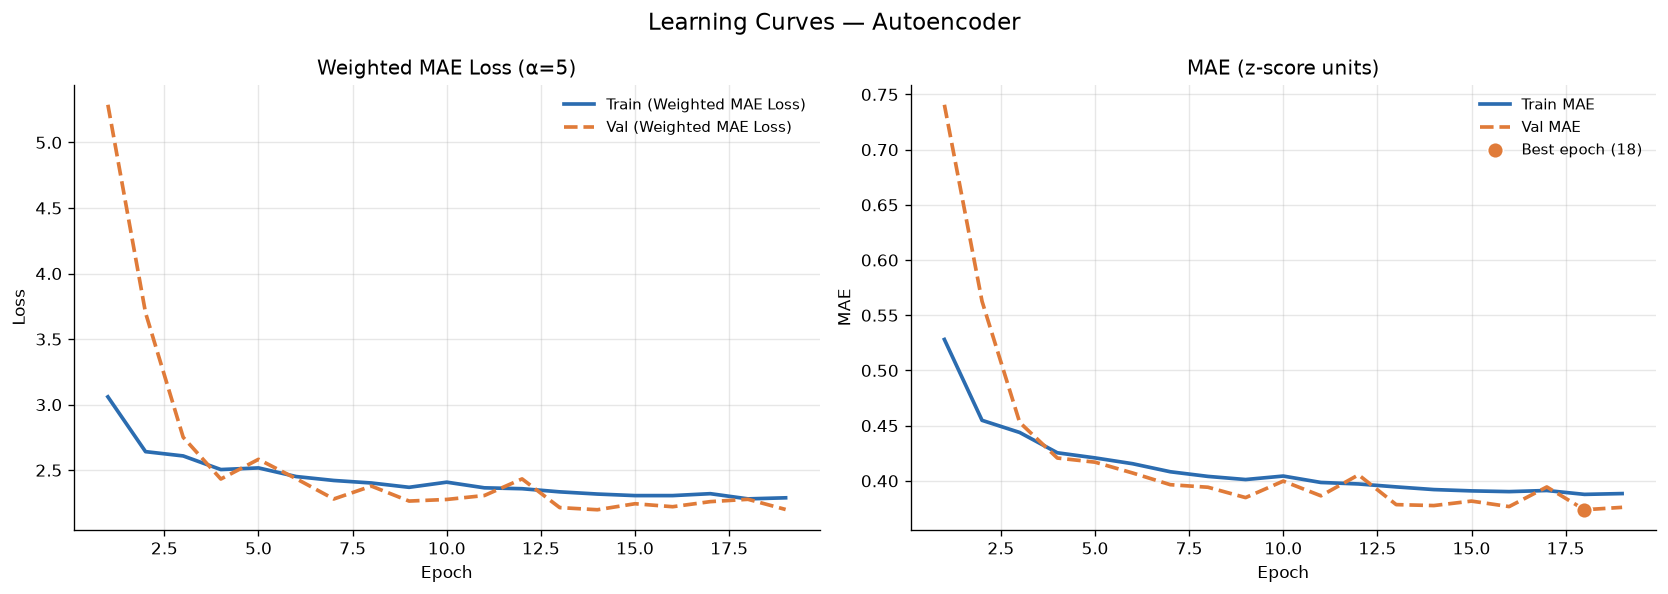

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

epoche = range(1, len(history.history["loss"]) + 1)
best_epoch_mae = int(np.argmin(history.history["val_mae"])) + 1
best_val_mae   = min(history.history["val_mae"])

# ── Panel 1: Weighted loss (the one actually used for training/EarlyStopping) ─
ax = axes[0]
ax.plot(epoche, history.history["loss"],     label="Train (Weighted MAE Loss)", color="#2b6cb0", linewidth=2.2)
ax.plot(epoche, history.history["val_loss"], label="Val (Weighted MAE Loss)",   color="#e07b39", linewidth=2.2, linestyle="--")
ax.set_title("Weighted MAE Loss (α=5)", fontsize=12)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
for s in ["top", "right"]: ax.spines[s].set_visible(False)

# ── Panel 2: Plain MAE (the metric comparable with the thresholds) ────────────
ax = axes[1]
ax.plot(epoche, history.history["mae"],     label="Train MAE", color="#2b6cb0", linewidth=2.2)
ax.plot(epoche, history.history["val_mae"], label="Val MAE",   color="#e07b39", linewidth=2.2, linestyle="--")
ax.scatter([best_epoch_mae], [best_val_mae], color="#e07b39", edgecolor="white", s=90, zorder=5,
           label=f"Best epoch ({best_epoch_mae})")
ax.set_title("MAE (z-score units)", fontsize=12)
ax.set_xlabel("Epoch"); ax.set_ylabel("MAE")
ax.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9)
for s in ["top", "right"]: ax.spines[s].set_visible(False)

fig.suptitle("Learning Curves — Autoencoder", fontsize=14)
plt.tight_layout()
plt.savefig("loss_curve_autoencoder.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Calcolo soglie di anomalia dinamiche

Invece di un'unica soglia MAE globale, calcoliamo **24 soglie distinte**  
(24 ore).
Ogni errore orario viene confrontato con la soglia calibrata sul comportamento tipico di quella fascia.


Soglie calcolate: 24 (una per ora)
Metodo: mediana + 2.5 × MAD


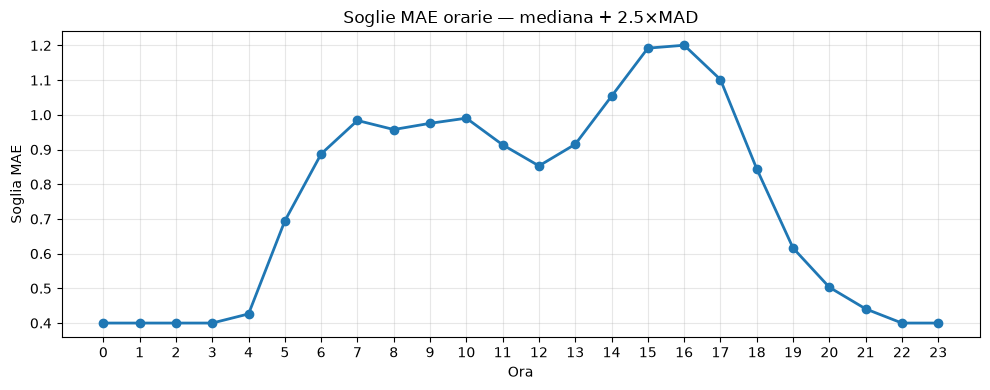

In [15]:
from scipy.stats import median_abs_deviation

# ── Predict sul validation set ───────────────────────────────────────────────
X_val_pred = autoencoder.predict(X_val, verbose=0)
mae_val    = np.abs(X_val - X_val_pred)

n_val, n_feat_wide = mae_val.shape
n_ore_tot = n_feat_wide // len(FEATURE_COLS)

# ── Parametro: quante MAD sopra la mediana consideriamo soglia ───────────────
N_MAD = 2.5  # regola questo valore (tipicamente 2.5–5)
SOGLIA_MINIMA = 0.4  # regola in base alla tua scala

# ── 24 soglie — una per ora del giorno ───────────────────────────────────────
soglie_orarie = {}

for ora in range(24):
    cols   = [g * 24 + ora for g in range(N_GIORNI_CAMP) if g * 24 + ora < n_ore_tot]
    errori = mae_val[:, cols].flatten()
    
    mediana = np.median(errori)
    mad     = median_abs_deviation(errori, scale=1.0)  # scale=1 → MAD "grezza"
    
    soglie_orarie[ora] = max(float(mediana + N_MAD * mad), SOGLIA_MINIMA)

# ── Riepilogo ─────────────────────────────────────────────────────────────────
df_soglie = pd.DataFrame(
    [{"ora": k, "soglia_mae": v} for k, v in soglie_orarie.items()]
).set_index("ora")

print(f"Soglie calcolate: 24 (una per ora)")
print(f"Metodo: mediana + {N_MAD} × MAD")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_soglie.index, df_soglie["soglia_mae"], marker="o", linewidth=2)
ax.set_xlabel("Ora")
ax.set_ylabel("Soglia MAE")
ax.set_xticks(range(24))
ax.set_title(f"Soglie MAE orarie — mediana + {N_MAD}×MAD")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Salvataggio modello e scaler

Salviamo il modello Keras e i parametri dello scaler (necessari per l'inference).


In [16]:
import json as _json

autoencoder.save("autoencoder_traffico.keras")

# Salva le soglie dinamiche
with open("soglie_dinamiche.json", "w") as f:
    _json.dump(soglie_orarie, f, indent=2)

# serie_stats.json e' gia' stato salvato nella sezione 3-bis
print("Salvato: autoencoder_traffico.keras")
print("Salvato: soglie_dinamiche.json")
print(f"Soglie totali   : {len(soglie_orarie)} (24 ore x 4 tipi di giorno)")
print(f"Serie nel scaler: {len(scaler.stats_):,} (tutte le province incluse quelle di test)")


Salvato: autoencoder_traffico.keras
Salvato: soglie_dinamiche.json
Soglie totali   : 24 (24 ore x 4 tipi di giorno)
Serie nel scaler: 27,154 (tutte le province incluse quelle di test)


In [ ]:
import json as _json
import keras as keras_load

PROVINCIA = "GO"
INIZIO    = pd.Timestamp("2025-11-01")

ae_saved = keras_load.models.load_model("autoencoder_traffico.keras")
ì
with open("serie_stats.json", "r") as f:
    scaler_saved = SeriesScaler.from_dict(_json.load(f))ì
with open("soglie_dinamiche.json", "r") as f:
    soglie_orarie_saved = {int(k): v for k, v in _json.load(f).items()}

def get_soglia(ts: pd.Timestamp) -> float:
    return soglie_orarie_saved.get(ts.hour, float("nan"))

df_prov = pd.read_parquet(f"C:/Users/sissilollo/OneDrive - Alma Mater Studiorum Università di Bologna/Desktop/Nowcasting - Giacobazzi/output_province/traffico_{PROVINCIA}.parquet")
print(df_prov["comune_amm"].unique())



['B712' 'D014' 'D312' 'D321' 'D504' 'D645' 'E098' 'E124' 'E125' 'E952'
 'F081' 'F356' 'F710' 'F767' 'H514' 'H531' 'H665' 'H787' 'H845' 'H964'
 'I082' 'I479' 'I939' 'L474' 'M043']


In [54]:
COMUNE    = "h514".upper()
print(df_prov[df_prov["comune_amm"] == COMUNE]["zona"].unique())

['B1' 'E1' 'R1']


In [55]:
ZONA = "R1".upper()

File caricato: traffico_GO.parquet


C:\Users\sissilollo\AppData\Local\Temp\ipykernel_1804\1031788588.py:27: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  fine = INIZIO + pd.Timedelta(days=N_GIORNI_CAMP - 1)


Comune: H514 | Zona: R1 | Provincia: GO
Finestra: 2025-11-01 → 2026-01-29  (2160h)
Mu serie: 23.40  |  Std serie: 17.03
Soglia media (scalata)  : 0.747921
Soglia media (orig)     : 12.73 veicoli/h
Ore anomale             : 238 / 2160  (11.0%)


C:\Users\sissilollo\AppData\Local\Temp\ipykernel_1804\1031788588.py:147: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  ax_mae.bar(t_plot, mae_sc, color=colori, width=pd.Timedelta(hours=1))
C:\Users\sissilollo\AppData\Local\Temp\ipykernel_1804\1031788588.py:165: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  width=pd.Timedelta(hours=1), label="Normal residual")
C:\Users\sissilollo\AppData\Local\Temp\ipykernel_1804\1031788588.py:167: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  width=pd.

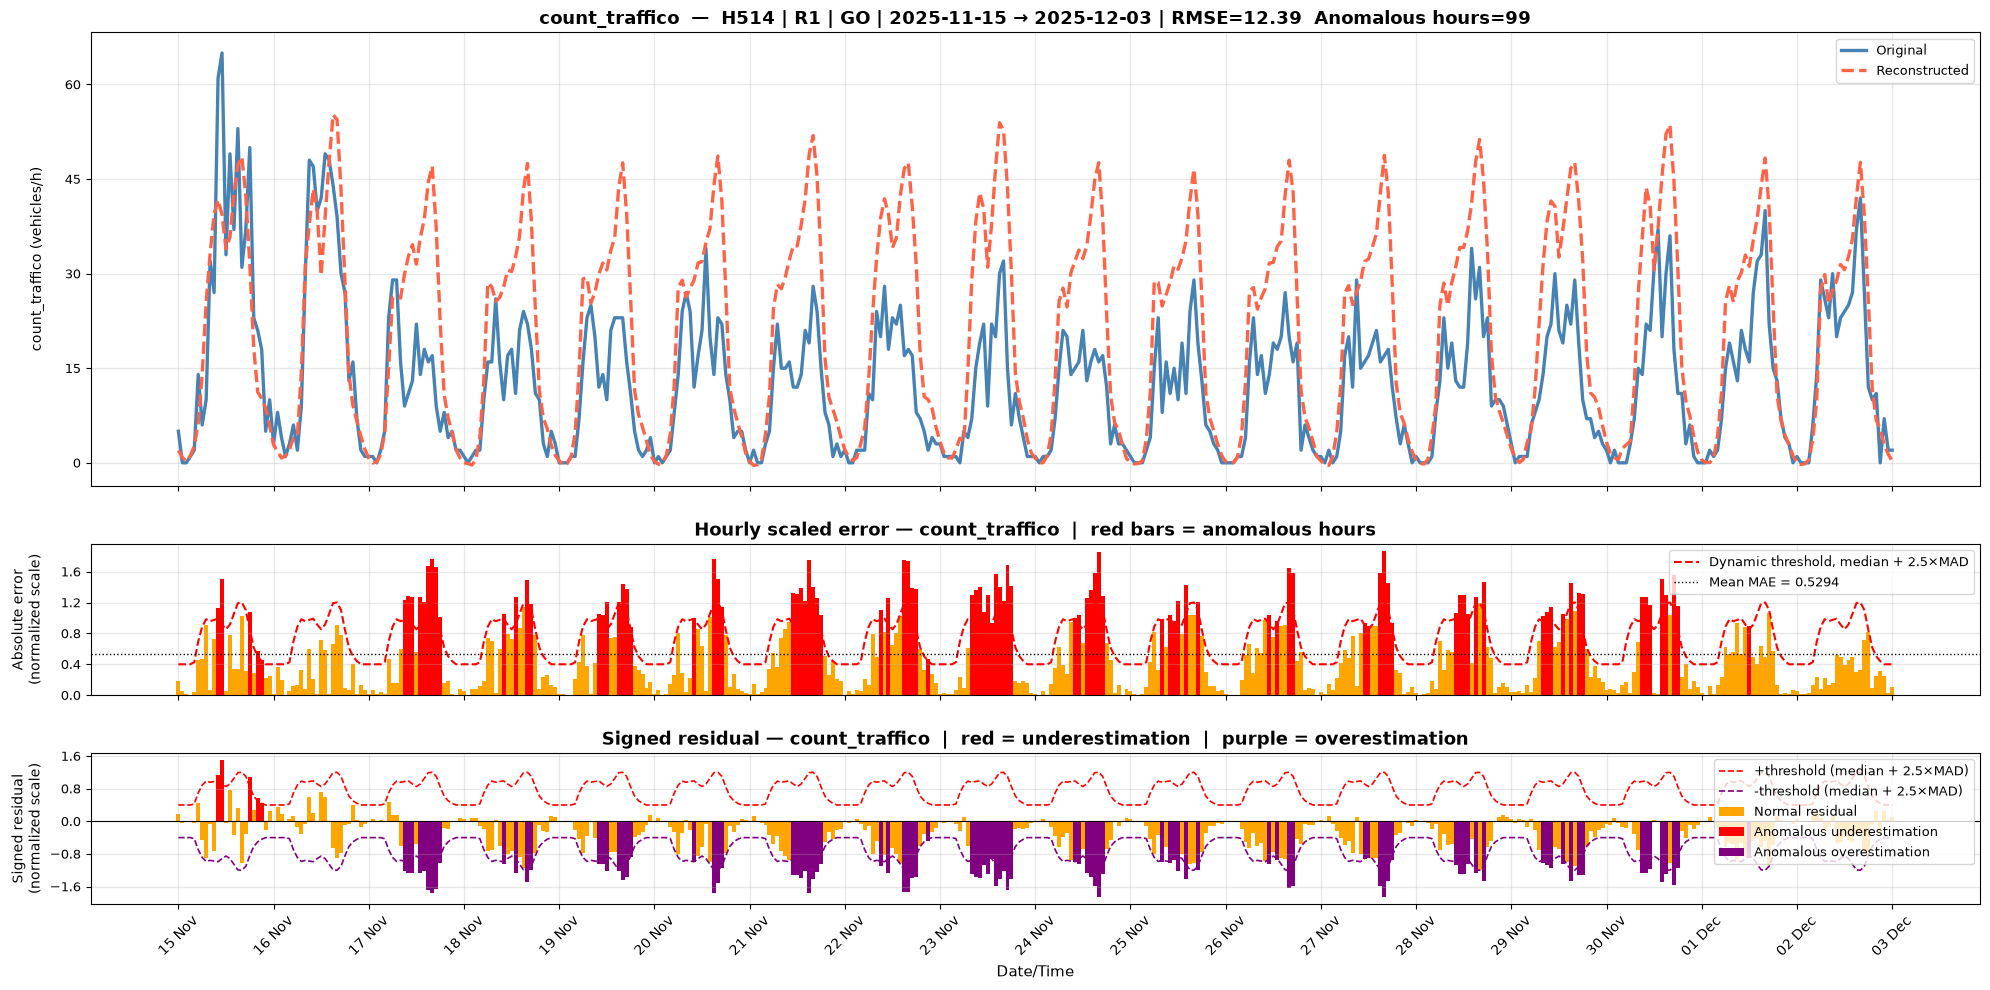

In [ ]:
path_provincia = next(
    (p for p in glob.glob(os.path.join(CARTELLA_PARQUET, "*.parquet"))
     if os.path.basename(p).replace(".parquet", "").endswith(PROVINCIA)),
    None
)
if path_provincia is None:
    raise FileNotFoundError(f"Nessun parquet trovato per la provincia: {PROVINCIA}")

print(f"File caricato: {os.path.basename(path_provincia)}")

df_prov = load_and_preprocess_single(path_provincia)

serie = df_prov[
    (df_prov["comune_amm"] == COMUNE) &
    (df_prov["zona"]       == ZONA)
].copy()

if serie.empty:
    raise ValueError(f"Serie non trovata: comune={COMUNE}, zona={ZONA}")

pivot = serie.pivot_table(
    index="giorno", columns="ora", values=FEATURE_COLS, aggfunc="first"
)
pivot.columns = [f"{feat}_{int(h)}" for feat, h in pivot.columns]
pivot = pivot.sort_index()

fine = INIZIO + pd.Timedelta(days=N_GIORNI_CAMP - 1)
if INIZIO not in pivot.index:
    raise ValueError(f"Data di inizio {INIZIO.date()} non presente nella serie.")
if fine not in pivot.index:
    raise ValueError(
        f"La finestra di {N_GIORNI_CAMP} giorni esce dai dati disponibili. "
        f"Ultimo giorno disponibile: {pivot.index[-1].date()}"
    )

finestra    = pivot.loc[INIZIO:fine]
data_inizio = finestra.index[0]

vettore = finestra.values.flatten().astype(np.float32)
ì
key_inf = (COMUNE, ZONA)
v_scaled, mu_inf, std_inf = scaler_saved.transform_single(vettore, key_inf)
pred_scaled = ae_saved.predict(v_scaled, verbose=0)

originale   = SeriesScaler.inverse_transform_single(v_scaled,    mu_inf, std_inf).flatten()
ricostruita = SeriesScaler.inverse_transform_single(pred_scaled, mu_inf, std_inf).flatten()
err_scalati = np.abs(v_scaled - pred_scaled).flatten()

n_ore = len(originale) // len(FEATURE_COLS)
t     = pd.date_range(data_inizio, periods=n_ore, freq="h")
ì
soglie_finestra = np.array([get_soglia(ts) for ts in t], dtype=np.float32)
ì
err_per_feature = err_scalati.reshape(len(FEATURE_COLS), n_ore)
ì
anomale_per_ora = np.any(err_per_feature > soglie_finestra, axis=0)  # shape (n_ore,)

anomale = err_scalati > np.tile(soglie_finestra, len(FEATURE_COLS))
soglia_or_media = soglie_finestra.mean() * std_inf

print(f"Comune: {COMUNE} | Zona: {ZONA} | Provincia: {PROVINCIA}")
print(f"Finestra: {data_inizio.date()} → {fine.date()}  ({n_ore}h)")
print(f"Mu serie: {mu_inf:.2f}  |  Std serie: {std_inf:.2f}")
print(f"Soglia media (scalata)  : {soglie_finestra.mean():.6f}")
print(f"Soglia media (orig)     : {soglia_or_media:.2f} veicoli/h")
print(f"Ore anomale             : {anomale_per_ora.sum()} / {n_ore}  ({anomale_per_ora.mean()*100:.1f}%)")

import matplotlib.dates as mdates

import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

START_GRAPHIC = pd.Timestamp("2025-11-15")
END_GRAPHIC   = pd.Timestamp("2025-12-03")

if START_GRAPHIC < data_inizio or END_GRAPHIC > fine:
    raise ValueError(
        f"START_GRAPHIC/END_GRAPHIC devono essere contenuti nella finestra calcolata "
        f"({data_inizio.date()} → {fine.date()})."
    )
if START_GRAPHIC >= END_GRAPHIC:
    raise ValueError("START_GRAPHIC deve precedere END_GRAPHIC.")

mask_plot = (t >= START_GRAPHIC) & (t <= END_GRAPHIC)
t_plot    = t[mask_plot]

n_feat = len(FEATURE_COLS)

plt.close("all")
fig, axes = plt.subplots(
    n_feat * 3, 1,
    figsize=(20, 5 * n_feat * 2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1] * n_feat}
)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(True, alpha=0.90, linewidth=0.9)   # ← aggiunta qui

for i, feat in enumerate(FEATURE_COLS):
    s = i * n_ore
    e = s + n_ore

    orig    = originale[s:e][mask_plot]
    ricostr = ricostruita[s:e][mask_plot]
    mae_sc  = err_scalati[s:e][mask_plot]
    soglie_ = soglie_finestra[s:e][mask_plot]
    anom    = mae_sc > soglie_

    mae_medio = mae_sc.mean()
    rmse_glob = np.sqrt(np.mean((orig - ricostr) ** 2))

    ax_serie = axes[i * 3]
    ax_mae   = axes[i * 3 + 1]
    ax_resid = axes[i * 3 + 2]

    # ── Plot 1: serie originale vs ricostruita ────────────────────────────────
    ax_serie.plot(t_plot, orig,    color="steelblue", linewidth=2.4, label="Original")
    ax_serie.plot(t_plot, ricostr, color="tomato",    linewidth=2.4,
                  linestyle="--", label="Reconstructed")
    ax_serie.set_ylabel(f"{feat} (vehicles/h)", fontsize=10)
    ax_serie.set_title(
        f"{feat}  —  {COMUNE} | {ZONA} | {PROVINCIA} | "
        f"{START_GRAPHIC.date()} → {END_GRAPHIC.date()} | "
        f"RMSE={rmse_glob:.2f}  Anomalous hours={anom.sum()}",
        fontsize=13, fontweight="bold"
    )
    ax_serie.legend(loc="upper right", fontsize=9)
    ax_serie.grid(True, alpha=0.3)

    # ── Plot 2: errore assoluto scalato ───────────────────────────────────────
    colori = np.where(anom, "red", "orange")
    ax_mae.bar(t_plot, mae_sc, color=colori, width=pd.Timedelta(hours=1))
    ax_mae.plot(t_plot, soglie_, color="red", linewidth=1.5, linestyle="--",
                label=f"Dynamic threshold, median + {N_MAD}×MAD")
    ax_mae.axhline(mae_medio, color="black", linewidth=1, linestyle=":",
                   label=f"Mean MAE = {mae_medio:.4f}")
    ax_mae.set_ylabel("Absolute error\n(normalized scale)", fontsize=10)
    ax_mae.set_title(f"Hourly scaled error — {feat}  |  red bars = anomalous hours",
                      fontsize=13, fontweight="bold")
    ax_mae.legend(loc="upper right", fontsize=9)
    ax_mae.grid(True, alpha=0.3)

    # ── Plot 3: residuo con segno ──────────────────────────────────────────────
    residuo_sc = (v_scaled - pred_scaled).flatten()[s:e][mask_plot]
    sopra  = residuo_sc >  soglie_
    sotto  = residuo_sc < -soglie_
    normal = ~sopra & ~sotto

    ax_resid.bar(t_plot[normal], residuo_sc[normal], color="orange",
                 width=pd.Timedelta(hours=1), label="Normal residual")
    ax_resid.bar(t_plot[sopra],  residuo_sc[sopra],  color="red",
                 width=pd.Timedelta(hours=1), label="Anomalous underestimation")
    ax_resid.bar(t_plot[sotto],  residuo_sc[sotto],  color="purple",
                 width=pd.Timedelta(hours=1), label="Anomalous overestimation")
    ax_resid.plot(t_plot,  soglie_, color="red",    linewidth=1.2, linestyle="--",
                  label=f"+threshold (median + {N_MAD}×MAD)")
    ax_resid.plot(t_plot, -soglie_, color="purple", linewidth=1.2, linestyle="--",
                  label=f"-threshold (median + {N_MAD}×MAD)")
    ax_resid.axhline(0, color="black", linewidth=0.8)
    ax_resid.set_ylabel("Signed residual\n(normalized scale)", fontsize=10)
    ax_resid.set_title(f"Signed residual — {feat}  |  red = underestimation  |  purple = overestimation",
                        fontsize=13, fontweight="bold")
    ax_resid.legend(loc="upper right", fontsize=9)
    ax_resid.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date/Time", fontsize=11)

fig.align_ylabels(axes)                 # allinea tutte le etichette y sulla stessa colonna
plt.tight_layout(h_pad=2.0)        
plt.show()

Tasso di falsi positivi (per punto orario): 12.7311%
Finestre con almeno un falso positivo   : 99.9000%

Tasso di falsi positivi per ora:
      fp_rate
ora          
0    0.045850
1    0.025396
2    0.024598
3    0.080773
4    0.188901
5    0.164684
6    0.147844
7    0.135954
8    0.143513
9    0.145081
10   0.140170
11   0.135484
12   0.140936
13   0.140769
14   0.135203
15   0.137806
16   0.137682
17   0.130394
18   0.137506
19   0.155967
20   0.165927
21   0.169156
22   0.140564
23   0.085308


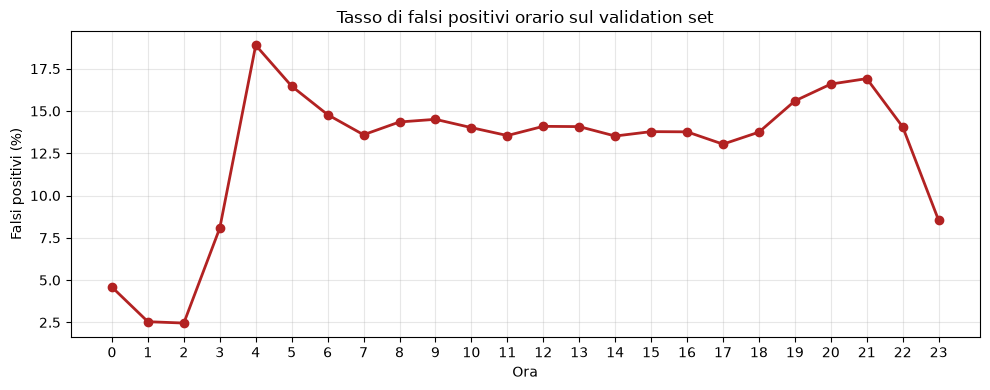

In [47]:
# ── Tasso di falsi positivi sul validation set ────────────────────────────────
# Il validation set proviene dallo stesso periodo/campionamento del training
# (nessuna anomalia strutturale nota), quindi ogni superamento soglia qui
# è per definizione un falso positivo.

flag_anomalia = np.zeros_like(mae_val, dtype=bool)

for ora in range(24):
    cols = [g * 24 + ora for g in range(N_GIORNI_CAMP) if g * 24 + ora < n_ore_tot]
    soglia_ora = soglie_orarie[ora]
    flag_anomalia[:, cols] = mae_val[:, cols] > soglia_ora

# ── Falso positivo per punto (ogni ora di ogni finestra) ──────────────────────
fp_rate_globale = flag_anomalia.mean()
print(f"Tasso di falsi positivi (per punto orario): {fp_rate_globale:.4%}")

# ── Falso positivo per finestra (almeno un'ora anomala nella finestra) ────────
fp_per_finestra = flag_anomalia.any(axis=1).mean()
print(f"Finestre con almeno un falso positivo   : {fp_per_finestra:.4%}")

# ── Breakdown per ora del giorno ───────────────────────────────────────────────
fp_per_ora = {}
for ora in range(24):
    cols = [g * 24 + ora for g in range(N_GIORNI_CAMP) if g * 24 + ora < n_ore_tot]
    fp_per_ora[ora] = flag_anomalia[:, cols].mean()

df_fp = pd.DataFrame(
    [{"ora": k, "fp_rate": v} for k, v in fp_per_ora.items()]
).set_index("ora")

print("\nTasso di falsi positivi per ora:")
print(df_fp)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_fp.index, df_fp["fp_rate"] * 100, marker="o", linewidth=2, color="firebrick")
ax.set_xlabel("Ora")
ax.set_ylabel("Falsi positivi (%)")
ax.set_xticks(range(24))
ax.set_title("Tasso di falsi positivi orario sul validation set")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Controlla quante serie sono nello scaler e cerca la serie di interesse
print(f"Serie totali nello scaler: {len(scaler_saved.stats_)}")

# Cerca tutte le chiavi che contengono H514
matches = [k for k in scaler_saved.stats_.keys() if "H514" in k[0]]
print(f"Chiavi con H514: {matches}")

# Mostra le prime 5 chiavi per capire il formato
print("Prime 5 chiavi:", list(scaler_saved.stats_.keys())[0:5])

Serie totali nello scaler: 27154
Chiavi con H514: [('H514', 'B1'), ('H514', 'E1'), ('H514', 'R1')]
Prime 5 chiavi: [('A089', 'B1'), ('A089', 'B2'), ('A089', 'B3'), ('A089', 'B4'), ('A089', 'B6')]
